# Sphere analysis with custom generated masks (w/ editable time intervals and comparing multiple independent objects in time)

## Libraries

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile

from pathlib import Path
from scipy import ndimage as ndi
from scipy.stats import pearsonr
from skimage import filters, measure, morphology

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams["figure.figsize"] = (7, 6)
plt.rcParams["image.cmap"] = "gray"

## Direct TIFF file loading

In [2]:
from pathlib import Path
import tifffile

# =========================
# DIRECT TIFF FILE PATH
# =========================
STACK_PATH = Path(
    #r"C:\Users\super\OneDrive\Desktop\Desktop1\20260210_Control4_Sphere_in_Vehicle_Fluo4_50nM_NAOH_Ca2+_5uM_a\20260210_Control4_Sphere_in_Vehicle_Fluo4_50nM_NAOH_Ca2+_5uM_a_bg01.ome.tif"
    #r"C:\Users\super\OneDrive\Desktop\Desktop1\20260210_Control2_Sphere_in_Vehicle_no_Fluos_a\20260210_Control2_Sphere_in_Vehicle_no_Fluos_a_bg01.ome.tif"
    #r"C:\Users\super\OneDrive\Desktop\Desktop1\20260210_Control2_Sphere_in_Vehiculo_no_Fluos_EDTA_2mM_a\20260210_Sphere_in_Vehiculo_no_Fluos_EDTA_2mM_A_bg01.ome.tif"
    #r"C:\Users\super\OneDrive\Desktop\Desktop1\Calibracion_fluorescencia_placa\Calibracion_fluorescencia_placa_bg01.ome.tif"
    #r"C:\Users\super\OneDrive\Desktop\Desktop1\Sphere_control_1\Ruido_Sensor_ROI\Ruido_Sensor_ROI_bg01.ome.tif"
    #r"C:\Users\super\OneDrive\Desktop\Desktop1\Vehicle_EDTA_2mM_0nM_Ca2+_2_spheres_A\Vehicle_EDTA_2mM_0nM_Ca2+_2_spheres_A_bg01.ome.tif"
    #r"C:\Users\super\OneDrive\Desktop\Desktop1\Vehicle_EDTA_2mM_0nM_Ca2+_3_spheres_B\Vehicle_EDTA_2mM_0nM_Ca2+_3_spheres_B_bg01.ome.tif"
    #r"C:\Users\super\OneDrive\Desktop\Desktop1\Vehicle_EDTA_2mM_0nM_Ca2+_3_spheres_fist_smash_on_table\Vehicle_EDTA_2mM_0nM_Ca2+_3_spheres_fist_smash_on_table_bg01.ome.tif"
    r"C:\Users\super\OneDrive\Desktop\Desktop2\BEAD_FocalCheck_Slide_LED100mA_Int20_2_BEAD_ROI_A\BEAD_FocalCheck_Slide_LED100mA_Int20_2_BEAD_ROI_A_bg01.ome.tif"
)

# =========================
# BASIC PATH CHECK
# =========================
print("Selected path:")
print(STACK_PATH)

print("\nPath exists:", STACK_PATH.exists())
print("Is file:", STACK_PATH.is_file())
print("Suffixes:", STACK_PATH.suffixes)

if not STACK_PATH.exists():
    raise FileNotFoundError(f"File not found:\n{STACK_PATH}")

if not STACK_PATH.is_file():
    raise FileNotFoundError(f"The path exists, but it is not a file:\n{STACK_PATH}")

# =========================
# LOAD TIFF STACK
# =========================
try:
    stack = tifffile.memmap(STACK_PATH)
    print("\nLoaded with tifffile.memmap()")
except Exception:
    stack = tifffile.imread(STACK_PATH)
    print("\nLoaded with tifffile.imread()")

print("Stack shape:", stack.shape)
print("Stack dtype:", stack.dtype)

selected_stack_path = STACK_PATH

Selected path:
C:\Users\super\OneDrive\Desktop\Desktop2\BEAD_FocalCheck_Slide_LED100mA_Int20_2_BEAD_ROI_A\BEAD_FocalCheck_Slide_LED100mA_Int20_2_BEAD_ROI_A_bg01.ome.tif

Path exists: True
Is file: True
Suffixes: ['.ome', '.tif']

Loaded with tifffile.memmap()
Stack shape: (48000, 64, 64)
Stack dtype: uint16


## Global variables and helper functions

In [27]:
# =========================
# GLOBAL SETTINGS
# =========================
EXPECTED_TOTAL_FRAMES = 48000
EXPECTED_HEIGHT = 64
EXPECTED_WIDTH = 64

USE_FULL_STACK_FOR_MASK = True
MASK_START_FRAME = 0
MASK_MEAN_FRAMES = 5000
MASK_PROJECTION_CHUNK_SIZE = 4000

THRESHOLD_ADU = 1
GAUSSIAN_SIGMA = 1.0
MASK_DILATION_ITERS = 1
MIN_MASK_AREA_PX = 9

# Analyze the full stack by default
ANALYSIS_INTERVALS = [(0, 48000)]

# Example alternatives:
# ANALYSIS_INTERVALS = [(5000, 15000)]
# ANALYSIS_INTERVALS = [(0, 5000), (12000, 18000), (30000, 36000)]

COM_CHUNK_SIZE = 4000
N_ITERATIONS = 100
BASE_RANDOM_SEED = 12345
QC_RANDOM_SEED = 12345

SHOW_PIXEL_GRID = False
MAX_POINTS_TO_PLOT = 4000

# =========================
# CUSTOM CIRCULAR ROI SETTINGS
# =========================
CUSTOM_MASK_RADIUS = 18
CUSTOM_MASK_X0 = 22.0
CUSTOM_MASK_Y0 = 41.0

# =========================
# INTERVAL HANDLING
# =========================
def validate_analysis_intervals(intervals, total_frames):
    if intervals is None or len(intervals) == 0:
        return [(0, total_frames)]

    validated_intervals = []

    for start_frame, end_frame in intervals:
        start_frame = int(start_frame)
        end_frame = int(end_frame)

        if start_frame < 0 or end_frame < 0:
            raise ValueError("Frame interval values must be non-negative.")

        if end_frame <= start_frame:
            raise ValueError(f"Invalid interval: ({start_frame}, {end_frame})")

        if end_frame > total_frames:
            raise ValueError(
                f"Interval ({start_frame}, {end_frame}) exceeds total frames ({total_frames})."
            )

        validated_intervals.append((start_frame, end_frame))

    return validated_intervals


def count_total_selected_frames(intervals):
    return sum(end_frame - start_frame for start_frame, end_frame in intervals)


# =========================
# STACK LOADING AND VALIDATION
# =========================
def open_tiff_stack(stack_path):
    stack_path = Path(stack_path)

    try:
        stack = tifffile.memmap(stack_path)
    except Exception:
        stack = tifffile.imread(stack_path)

    if stack.ndim != 3:
        raise ValueError(
            f"Expected a 3D TIFF stack with shape (frames, height, width), but got shape {stack.shape}"
        )

    return stack


def validate_stack_shape(stack, expected_height=None, expected_width=None, expected_frames=None):
    n_frames, height, width = stack.shape

    print(f"Stack shape detected: frames={n_frames}, height={height}, width={width}")

    if expected_height is not None and height != expected_height:
        print(f"Warning: detected height ({height}) differs from expected height ({expected_height})")

    if expected_width is not None and width != expected_width:
        print(f"Warning: detected width ({width}) differs from expected width ({expected_width})")

    if expected_frames is not None and n_frames != expected_frames:
        print(f"Warning: detected frames ({n_frames}) differs from expected frames ({expected_frames})")

    return n_frames, height, width


# =========================
# PIXEL MESH
# =========================
def build_pixel_mesh(height, width):
    y_mesh, x_mesh = np.indices((height, width), dtype=np.float64)
    return y_mesh, x_mesh


# =========================
# MEAN PROJECTION
# =========================
def compute_mean_projection(
    stack,
    use_full_stack=True,
    start_frame=0,
    n_frames=5000,
    chunk_size=4000,
):
    total_frames = stack.shape[0]

    if use_full_stack:
        frame_ranges = [(0, total_frames)]
        n_frames_used = total_frames
    else:
        end_frame = min(start_frame + n_frames, total_frames)
        frame_ranges = [(start_frame, end_frame)]
        n_frames_used = end_frame - start_frame

    if n_frames_used <= 0:
        raise ValueError("The number of frames used for the mean projection must be greater than zero.")

    accumulator = np.zeros(stack.shape[1:], dtype=np.float64)

    for range_start, range_end in frame_ranges:
        for chunk_start in range(range_start, range_end, chunk_size):
            chunk_end = min(chunk_start + chunk_size, range_end)
            chunk = np.asarray(stack[chunk_start:chunk_end], dtype=np.float64)
            accumulator += np.sum(chunk, axis=0)

    mean_projection = accumulator / n_frames_used
    return mean_projection


# =========================
# REAL OBJECT MASK GENERATION
# =========================
def generate_effective_mask(
    mean_projection,
    threshold_adu=130,
    gaussian_sigma=1.0,
    dilation_iters=1,
    min_mask_area_px=9,
):
    smoothed_projection = filters.gaussian(
        mean_projection.astype(np.float64),
        sigma=gaussian_sigma,
        preserve_range=True,
    )

    threshold_mask = smoothed_projection >= threshold_adu

    if not np.any(threshold_mask):
        raise ValueError(
            "No pixels survived the threshold. Lower THRESHOLD_ADU or inspect the mean projection."
        )

    seed_position = np.unravel_index(np.argmax(smoothed_projection), smoothed_projection.shape)

    labeled_mask = measure.label(threshold_mask, connectivity=2)
    seed_label = labeled_mask[seed_position]

    if seed_label == 0:
        raise ValueError("The seed pixel does not belong to a valid connected component.")

    effective_mask = labeled_mask == seed_label
    effective_mask = ndi.binary_fill_holes(effective_mask)

    effective_mask = morphology.remove_small_objects(
        effective_mask.astype(bool),
        min_size=1,
    )

    if dilation_iters > 0:
        effective_mask = ndi.binary_dilation(effective_mask, iterations=dilation_iters)

    effective_mask = effective_mask.astype(bool)

    if not np.any(effective_mask):
        raise ValueError("The final effective mask is empty after post-processing.")

    return {
        "smoothed_projection": smoothed_projection,
        "threshold_mask": threshold_mask,
        "effective_mask": effective_mask,
        "seed_position": seed_position,
    }


# =========================
# CIRCULAR CUSTOM MASK
# =========================
def create_circular_mask(height, width, center_x, center_y, radius):
    y_mesh, x_mesh = np.indices((height, width), dtype=np.float64)
    distance_sq = (x_mesh - center_x) ** 2 + (y_mesh - center_y) ** 2
    circular_mask = distance_sq <= (radius ** 2)
    return circular_mask.astype(bool)


# =========================
# QC HELPERS
# =========================
def add_pixel_grid(ax, height, width, alpha=0.15, linewidth=0.3):
    for x in range(width + 1):
        ax.axvline(x - 0.5, color="white", alpha=alpha, linewidth=linewidth)
    for y in range(height + 1):
        ax.axhline(y - 0.5, color="white", alpha=alpha, linewidth=linewidth)


def plot_real_mask_qc(
    mean_projection,
    smoothed_projection,
    threshold_mask,
    effective_mask,
    seed_position,
    show_pixel_grid=False,
):
    height, width = mean_projection.shape

    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

    axes[0].imshow(mean_projection)
    axes[0].scatter(seed_position[1], seed_position[0], s=40, marker="x")
    axes[0].set_title("Mean projection")
    axes[0].set_axis_off()

    axes[1].imshow(smoothed_projection)
    axes[1].scatter(seed_position[1], seed_position[0], s=40, marker="x")
    axes[1].set_title("Smoothed projection")
    axes[1].set_axis_off()

    axes[2].imshow(threshold_mask)
    axes[2].scatter(seed_position[1], seed_position[0], s=40, marker="x")
    axes[2].set_title("Threshold mask")
    axes[2].set_axis_off()

    axes[3].imshow(mean_projection)
    axes[3].contour(effective_mask.astype(np.uint8), levels=[0.5], linewidths=1.2)
    axes[3].scatter(seed_position[1], seed_position[0], s=40, marker="x")
    axes[3].set_title("Effective mask overlay")
    axes[3].set_axis_off()

    if show_pixel_grid:
        for ax in axes:
            add_pixel_grid(ax, height, width)

    plt.tight_layout()
    plt.show()


def plot_custom_mask_qc(mean_projection, custom_mask, center_x, center_y, radius, show_pixel_grid=False):
    height, width = custom_mask.shape

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

    axes[0].imshow(mean_projection)
    axes[0].scatter(center_x, center_y, s=40, marker="x")
    axes[0].set_title("Mean projection")
    axes[0].set_axis_off()

    axes[1].imshow(custom_mask)
    axes[1].scatter(center_x, center_y, s=40, marker="x")
    axes[1].set_title("Custom circular mask")
    axes[1].set_axis_off()

    axes[2].imshow(mean_projection, alpha=0.55)
    axes[2].contour(custom_mask.astype(np.uint8), levels=[0.5], linewidths=1.2)
    axes[2].scatter(center_x, center_y, s=40, marker="x")
    axes[2].set_title(f"Custom mask overlay (r={radius})")
    axes[2].set_axis_off()

    if show_pixel_grid:
        for ax in axes:
            add_pixel_grid(ax, height, width)

    plt.tight_layout()
    plt.show()


# =========================
# RANDOM CLASS ASSIGNMENT
# =========================
def assign_random_classes_from_mask(mask_to_use, random_seed=None):
    rng = np.random.default_rng(random_seed)

    mask_y, mask_x = np.nonzero(mask_to_use)
    n_pixels = mask_y.size

    if n_pixels < 2:
        raise ValueError("The selected mask must contain at least 2 pixels.")

    pixel_indices = np.arange(n_pixels)
    rng.shuffle(pixel_indices)

    split_index = n_pixels // 2

    class_a_indices = pixel_indices[:split_index]
    class_b_indices = pixel_indices[split_index:]

    class_a_selector = np.zeros(n_pixels, dtype=bool)
    class_b_selector = np.zeros(n_pixels, dtype=bool)

    class_a_selector[class_a_indices] = True
    class_b_selector[class_b_indices] = True

    class_a_mask = np.zeros_like(mask_to_use, dtype=bool)
    class_b_mask = np.zeros_like(mask_to_use, dtype=bool)

    class_a_mask[mask_y[class_a_selector], mask_x[class_a_selector]] = True
    class_b_mask[mask_y[class_b_selector], mask_x[class_b_selector]] = True

    return {
        "mask_y": mask_y,
        "mask_x": mask_x,
        "class_a_selector": class_a_selector,
        "class_b_selector": class_b_selector,
        "class_a_mask": class_a_mask,
        "class_b_mask": class_b_mask,
        "n_pixels_total": n_pixels,
        "n_pixels_class_a": int(class_a_selector.sum()),
        "n_pixels_class_b": int(class_b_selector.sum()),
    }


def plot_class_assignment_qc(mean_projection, mask_to_use, class_a_mask, class_b_mask):
    rgb_overlay = np.zeros((*mask_to_use.shape, 3), dtype=np.float32)

    rgb_overlay[..., 0] = class_a_mask.astype(np.float32)
    rgb_overlay[..., 1] = class_b_mask.astype(np.float32)
    rgb_overlay[..., 2] = 0.0

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

    axes[0].imshow(mean_projection)
    axes[0].set_title("Mean projection")
    axes[0].set_axis_off()

    axes[1].imshow(mask_to_use)
    axes[1].set_title("Analysis mask")
    axes[1].set_axis_off()

    axes[2].imshow(mean_projection, alpha=0.55)
    axes[2].imshow(rgb_overlay, alpha=0.65)
    axes[2].set_title("Class A/B assignment")
    axes[2].set_axis_off()

    plt.tight_layout()
    plt.show()


# =========================
# MASKED TRACE EXTRACTION
# =========================
def extract_masked_pixel_traces(
    stack,
    mask_to_use,
    analysis_intervals=None,
    chunk_size=4000,
    output_dtype=np.float32,
):
    mask_y, mask_x = np.nonzero(mask_to_use)

    total_frames = stack.shape[0]
    validated_intervals = validate_analysis_intervals(analysis_intervals, total_frames)
    total_selected_frames = count_total_selected_frames(validated_intervals)

    n_pixels = mask_y.size
    masked_traces = np.empty((total_selected_frames, n_pixels), dtype=output_dtype)
    frame_indices = np.empty(total_selected_frames, dtype=int)

    write_start = 0

    for start_frame, end_frame in validated_intervals:
        interval_length = end_frame - start_frame
        frame_indices[write_start:write_start + interval_length] = np.arange(start_frame, end_frame)

        local_write_start = write_start

        for chunk_start in range(start_frame, end_frame, chunk_size):
            chunk_end = min(chunk_start + chunk_size, end_frame)
            chunk = np.asarray(stack[chunk_start:chunk_end], dtype=output_dtype)

            local_chunk_start = local_write_start + (chunk_start - start_frame)
            local_chunk_end = local_chunk_start + (chunk_end - chunk_start)

            masked_traces[local_chunk_start:local_chunk_end] = chunk[:, mask_y, mask_x]

        write_start += interval_length

    return masked_traces, mask_y.astype(np.float64), mask_x.astype(np.float64), frame_indices


# =========================
# CENTER OF MASS
# =========================
def compute_com_series_from_traces(masked_traces, mask_x, mask_y, class_selector, frame_indices=None):
    """
    Compute the 2D center of mass frame by frame using the explicit weighted-sum formula.

    x_com(t) = sum( I_i(t) * x_i ) / sum( I_i(t) )
    y_com(t) = sum( I_i(t) * y_i ) / sum( I_i(t) )
    """

    # Select only the pixels that belong to the chosen class or mask
    class_traces = masked_traces[:, class_selector]
    class_x = mask_x[class_selector]
    class_y = mask_y[class_selector]

    n_frames = class_traces.shape[0]

    # Initialize output arrays
    x_com = np.full(n_frames, np.nan, dtype=np.float64)
    y_com = np.full(n_frames, np.nan, dtype=np.float64)
    intensity_sum = np.full(n_frames, np.nan, dtype=np.float64)

    # Compute COM explicitly for each frame
    for frame_idx in range(n_frames):
        frame_intensities = class_traces[frame_idx]

        # Denominator: total intensity in the selected pixels for this frame
        total_intensity = np.sum(frame_intensities)
        intensity_sum[frame_idx] = total_intensity

        # Avoid division by zero
        if total_intensity <= 0:
            continue

        # Numerators: weighted spatial sums
        numerator_x = np.sum(frame_intensities * class_x)
        numerator_y = np.sum(frame_intensities * class_y)

        # Center of mass coordinates
        x_com[frame_idx] = numerator_x / total_intensity
        y_com[frame_idx] = numerator_y / total_intensity

    # Keep the original frame numbers if provided
    if frame_indices is None:
        frame_indices = np.arange(n_frames, dtype=int)

    com_table = pd.DataFrame(
        {
            "frame": frame_indices,
            "x_com": x_com,
            "y_com": y_com,
            "intensity_sum": intensity_sum,
        }
    )

    return com_table


# =========================
# CORRELATION
# =========================
def safe_pearson_correlation(series_a, series_b):
    series_a = np.asarray(series_a, dtype=np.float64)
    series_b = np.asarray(series_b, dtype=np.float64)

    valid = np.isfinite(series_a) & np.isfinite(series_b)

    if np.sum(valid) < 3:
        return np.nan

    a = series_a[valid]
    b = series_b[valid]

    if np.std(a) == 0 or np.std(b) == 0:
        return np.nan

    return pearsonr(a, b)[0]


def compute_com_correlation_summary(com_a, com_b):
    corr_x = safe_pearson_correlation(com_a["x_com"].values, com_b["x_com"].values)
    corr_y = safe_pearson_correlation(com_a["y_com"].values, com_b["y_com"].values)
    corr_mean_xy = np.nanmean([corr_x, corr_y])

    summary = {
        "corr_x": corr_x,
        "corr_y": corr_y,
        "corr_mean_xy": corr_mean_xy,
    }

    return summary


# =========================
# COM QC PLOT
# =========================
def plot_com_series(com_a, com_b, analysis_intervals=None, max_points_to_plot=4000):
    if analysis_intervals is None:
        analysis_intervals = [(int(com_a["frame"].min()), int(com_a["frame"].max()) + 1)]

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    points_per_interval = max(50, max_points_to_plot // max(1, len(analysis_intervals)))

    for interval_index, (start_frame, end_frame) in enumerate(analysis_intervals):
        mask_a = (com_a["frame"] >= start_frame) & (com_a["frame"] < end_frame)
        mask_b = (com_b["frame"] >= start_frame) & (com_b["frame"] < end_frame)

        com_a_interval = com_a.loc[mask_a].copy()
        com_b_interval = com_b.loc[mask_b].copy()

        if len(com_a_interval) == 0 or len(com_b_interval) == 0:
            continue

        if len(com_a_interval) > points_per_interval:
            sampled_indices = np.linspace(
                0,
                len(com_a_interval) - 1,
                points_per_interval
            ).astype(int)

            com_a_interval = com_a_interval.iloc[sampled_indices]
            com_b_interval = com_b_interval.iloc[sampled_indices]

        label_a = "Class A" if interval_index == 0 else None
        label_b = "Class B" if interval_index == 0 else None

        axes[0].plot(
            com_a_interval["frame"].values,
            com_a_interval["x_com"].values,
            linewidth=1.0,
            label=label_a,
        )
        axes[0].plot(
            com_b_interval["frame"].values,
            com_b_interval["x_com"].values,
            linewidth=1.0,
            label=label_b,
        )

        axes[1].plot(
            com_a_interval["frame"].values,
            com_a_interval["y_com"].values,
            linewidth=1.0,
            label=label_a,
        )
        axes[1].plot(
            com_b_interval["frame"].values,
            com_b_interval["y_com"].values,
            linewidth=1.0,
            label=label_b,
        )

    axes[0].set_ylabel("X COM (px)")
    axes[0].set_title("X center of mass vs time")
    axes[0].legend()

    axes[1].set_xlabel("Frame")
    axes[1].set_ylabel("Y COM (px)")
    axes[1].set_title("Y center of mass vs time")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


# =========================
# ITERATIVE ANALYSIS
# =========================
def run_com_correlation_iterations(
    masked_traces,
    mask_x,
    mask_y,
    frame_indices,
    n_iterations=100,
    base_seed=12345,
    report_every=10,
):
    n_pixels = mask_x.size
    results = []

    for iteration_index in range(n_iterations):
        current_seed = base_seed + iteration_index

        pixel_indices = np.arange(n_pixels)
        rng = np.random.default_rng(current_seed)
        rng.shuffle(pixel_indices)

        split_index = n_pixels // 2

        class_a_selector = np.zeros(n_pixels, dtype=bool)
        class_b_selector = np.zeros(n_pixels, dtype=bool)

        class_a_selector[pixel_indices[:split_index]] = True
        class_b_selector[pixel_indices[split_index:]] = True

        com_a = compute_com_series_from_traces(
            masked_traces=masked_traces,
            mask_x=mask_x,
            mask_y=mask_y,
            class_selector=class_a_selector,
            frame_indices=frame_indices,
        )

        com_b = compute_com_series_from_traces(
            masked_traces=masked_traces,
            mask_x=mask_x,
            mask_y=mask_y,
            class_selector=class_b_selector,
            frame_indices=frame_indices,
        )

        corr_summary = compute_com_correlation_summary(com_a, com_b)

        results.append(
            {
                "iteration": iteration_index + 1,
                "seed": current_seed,
                "n_pixels_class_a": int(class_a_selector.sum()),
                "n_pixels_class_b": int(class_b_selector.sum()),
                "corr_x": corr_summary["corr_x"],
                "corr_y": corr_summary["corr_y"],
                "corr_mean_xy": corr_summary["corr_mean_xy"],
            }
        )

        if (iteration_index + 1) % report_every == 0 or iteration_index == 0:
            print(f"Completed iteration {iteration_index + 1}/{n_iterations}")

    results_df = pd.DataFrame(results)
    return results_df

## Load stack, verify dimensions, compute mean projection, and QC of the real-object mask

Stack shape detected: frames=48000, height=64, width=64
Pixel mesh shape: (64, 64)
Mask projection mode: full stack
Frames used for mask projection: 0 to 47999
Real effective mask pixels: 4096
Seed position: (np.int64(45), np.int64(31))


C:\Users\super\AppData\Local\Temp\ipykernel_24996\2446868715.py:186: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  effective_mask = morphology.remove_small_objects(


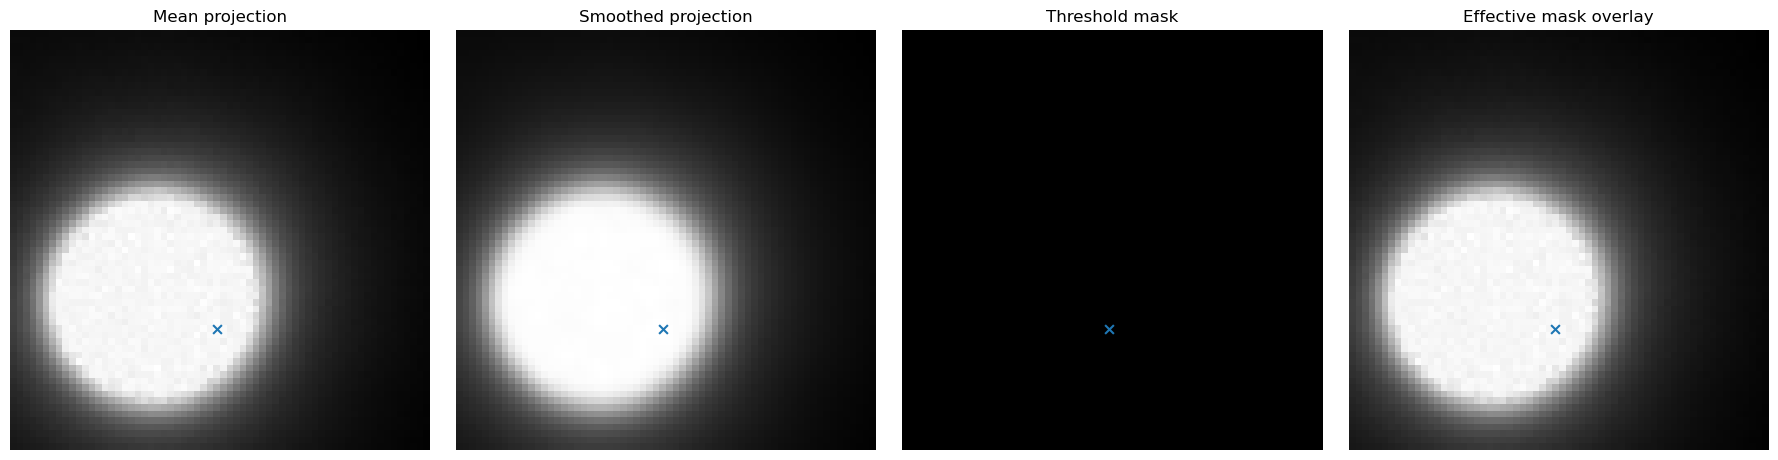

In [28]:
# =========================
# STACK LOAD
# =========================
stack = open_tiff_stack(selected_stack_path)
n_frames, height, width = validate_stack_shape(
    stack,
    expected_height=EXPECTED_HEIGHT,
    expected_width=EXPECTED_WIDTH,
    expected_frames=EXPECTED_TOTAL_FRAMES,
)

# =========================
# PIXEL MESH
# =========================
y_mesh, x_mesh = build_pixel_mesh(height, width)

print(f"Pixel mesh shape: {y_mesh.shape}")

# =========================
# MEAN PROJECTION FOR REFERENCE
# =========================
mean_projection = compute_mean_projection(
    stack=stack,
    use_full_stack=USE_FULL_STACK_FOR_MASK,
    start_frame=MASK_START_FRAME,
    n_frames=MASK_MEAN_FRAMES,
    chunk_size=MASK_PROJECTION_CHUNK_SIZE,
)

if USE_FULL_STACK_FOR_MASK:
    print("Mask projection mode: full stack")
    print(f"Frames used for mask projection: 0 to {n_frames - 1}")
else:
    print("Mask projection mode: partial stack")
    print(f"Frames used for mask projection: {MASK_START_FRAME} to {min(MASK_START_FRAME + MASK_MEAN_FRAMES, n_frames) - 1}")

# =========================
# REAL OBJECT MASK QC
# =========================
mask_results = generate_effective_mask(
    mean_projection=mean_projection,
    threshold_adu=THRESHOLD_ADU,
    gaussian_sigma=GAUSSIAN_SIGMA,
    dilation_iters=MASK_DILATION_ITERS,
    min_mask_area_px=MIN_MASK_AREA_PX,
)

smoothed_projection = mask_results["smoothed_projection"]
threshold_mask = mask_results["threshold_mask"]
effective_mask = mask_results["effective_mask"]
seed_position = mask_results["seed_position"]

print(f"Real effective mask pixels: {np.sum(effective_mask)}")
print(f"Seed position: {seed_position}")

plot_real_mask_qc(
    mean_projection=mean_projection,
    smoothed_projection=smoothed_projection,
    threshold_mask=threshold_mask,
    effective_mask=effective_mask,
    seed_position=seed_position,
    show_pixel_grid=SHOW_PIXEL_GRID,
)

## Create the custom circular mask and show QC

Custom mask pixels: 1009
Custom mask center (x0, y0): (22.0, 41.0)
Custom mask radius: 18
Coordinate convention: x increases from left to right, y increases from top to bottom.
Top-left pixel center is approximately (0, 0) and bottom-right pixel center is approximately (63, 63).


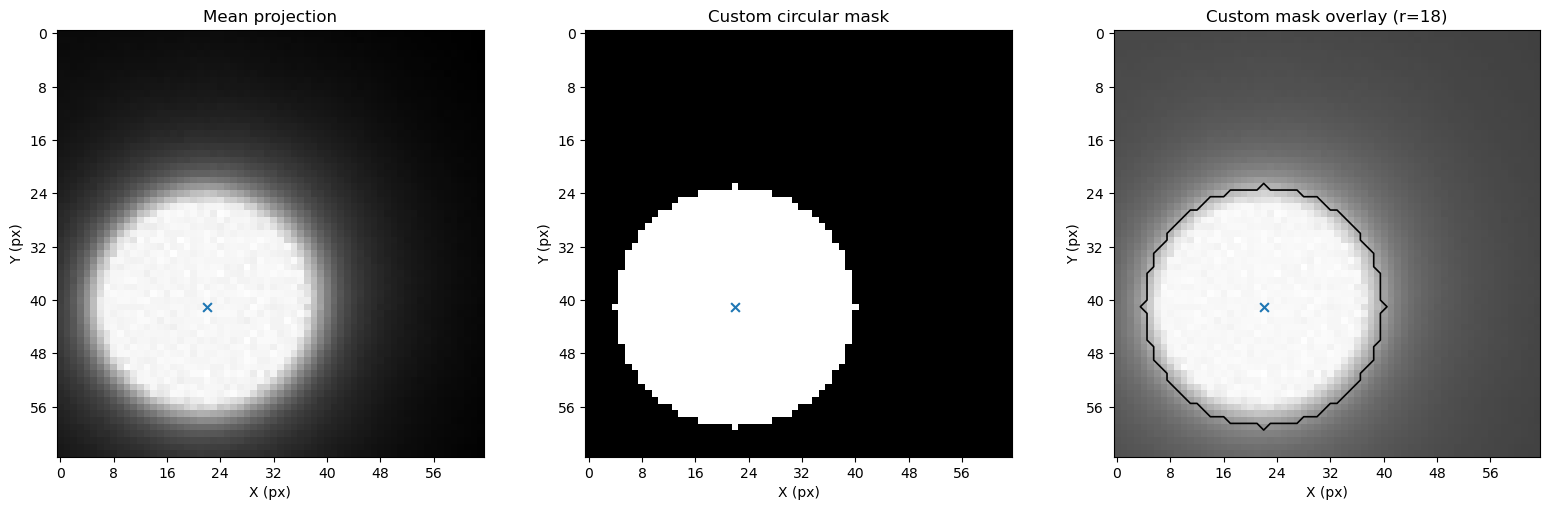

Analysis mask pixels: 1009


In [29]:
# =========================
# CUSTOM CIRCULAR MASK
# =========================
custom_mask = create_circular_mask(
    height=height,
    width=width,
    center_x=CUSTOM_MASK_X0,
    center_y=CUSTOM_MASK_Y0,
    radius=CUSTOM_MASK_RADIUS,
)

print(f"Custom mask pixels: {np.sum(custom_mask)}")
print(f"Custom mask center (x0, y0): ({CUSTOM_MASK_X0}, {CUSTOM_MASK_Y0})")
print(f"Custom mask radius: {CUSTOM_MASK_RADIUS}")
print("Coordinate convention: x increases from left to right, y increases from top to bottom.")
print("Top-left pixel center is approximately (0, 0) and bottom-right pixel center is approximately (63, 63).")

# =========================
# QC WITH FOV AXES
# =========================
tick_step = 8

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: mean projection
axes[0].imshow(mean_projection, origin="upper", interpolation="nearest")
axes[0].scatter(CUSTOM_MASK_X0, CUSTOM_MASK_Y0, s=40, marker="x")
axes[0].set_title("Mean projection")
axes[0].set_xlabel("X (px)")
axes[0].set_ylabel("Y (px)")

# Panel 2: custom mask
axes[1].imshow(custom_mask, origin="upper", interpolation="nearest")
axes[1].scatter(CUSTOM_MASK_X0, CUSTOM_MASK_Y0, s=40, marker="x")
axes[1].set_title("Custom circular mask")
axes[1].set_xlabel("X (px)")
axes[1].set_ylabel("Y (px)")

# Panel 3: overlay
axes[2].imshow(mean_projection, origin="upper", interpolation="nearest", alpha=0.75)
axes[2].contour(custom_mask.astype(np.uint8), levels=[0.5], linewidths=1.2)
axes[2].scatter(CUSTOM_MASK_X0, CUSTOM_MASK_Y0, s=40, marker="x")
axes[2].set_title(f"Custom mask overlay (r={CUSTOM_MASK_RADIUS})")
axes[2].set_xlabel("X (px)")
axes[2].set_ylabel("Y (px)")

for ax in axes:
    ax.set_xlim(-0.5, width - 0.5)
    ax.set_ylim(height - 0.5, -0.5)
    ax.set_xticks(np.arange(0, width, tick_step))
    ax.set_yticks(np.arange(0, height, tick_step))

    if SHOW_PIXEL_GRID:
        ax.set_xticks(np.arange(-0.5, width, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, height, 1), minor=True)
        ax.grid(which="minor", color="white", alpha=0.15, linewidth=0.3)

plt.tight_layout()
plt.show()

# =========================
# SELECT THE MASK USED FOR ANALYSIS
# =========================
analysis_mask = custom_mask
print(f"Analysis mask pixels: {np.sum(analysis_mask)}")

## Random class assignment and QC visualization over the custom mask

Total analysis mask pixels: 1009
Class A pixels: 504
Class B pixels: 505


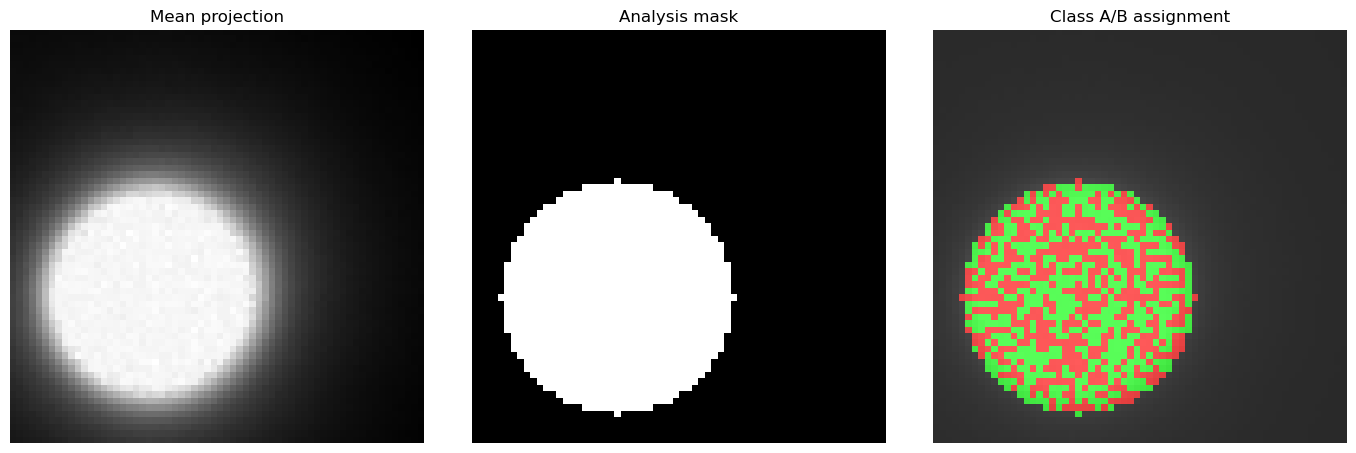

In [30]:
# =========================
# SINGLE RANDOM ASSIGNMENT
# =========================
single_assignment = assign_random_classes_from_mask(
    mask_to_use=analysis_mask,
    random_seed=QC_RANDOM_SEED,
)

class_a_mask = single_assignment["class_a_mask"]
class_b_mask = single_assignment["class_b_mask"]

print(f"Total analysis mask pixels: {single_assignment['n_pixels_total']}")
print(f"Class A pixels: {single_assignment['n_pixels_class_a']}")
print(f"Class B pixels: {single_assignment['n_pixels_class_b']}")

# =========================
# QC
# =========================
plot_class_assignment_qc(
    mean_projection=mean_projection,
    mask_to_use=analysis_mask,
    class_a_mask=class_a_mask,
    class_b_mask=class_b_mask,
)

## Extract traces from the custom mask, compute COM series, and calculate one-run correlation

Masked traces shape: (48000, 1009)
Selected frame intervals: [(0, 48000)]
Total selected frames: 48000
First selected frame: 0
Last selected frame: 47999
Single configuration correlation summary:
corr_x: 0.9644099254389857
corr_y: 0.9580241264288774
corr_mean_xy: 0.9612170259339315


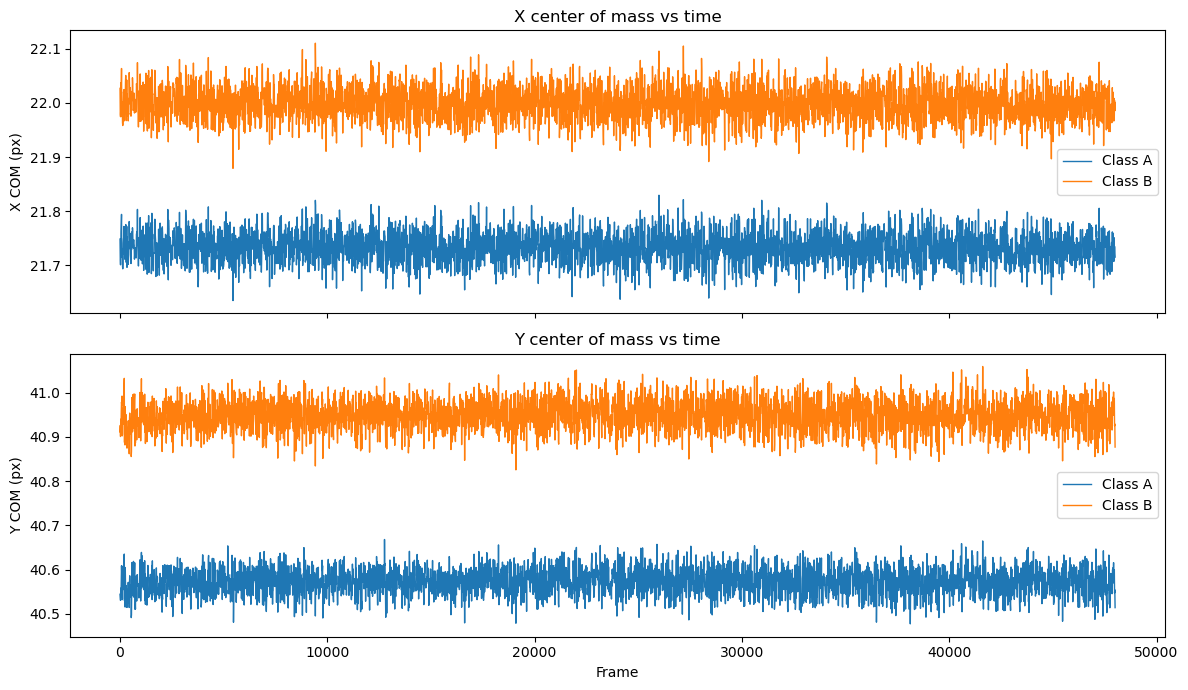

,frame,x_com,y_com,intensity_sum
0,0,21.748654,40.544439,551256.0
1,1,21.745206,40.553813,551701.0
2,2,21.724231,40.588208,551410.0
3,3,21.721155,40.583806,550657.0
4,4,21.706728,40.573423,550503.0


,frame,x_com,y_com,intensity_sum
0,0,22.026851,40.911247,547431.0
1,1,22.023158,40.938332,547938.0
2,2,21.998573,40.972283,547853.0
3,3,21.987431,40.967451,547120.0
4,4,21.971877,40.950779,546356.0


In [31]:
# =========================
# EXTRACT MASKED PIXEL TRACES
# =========================
masked_traces, mask_y, mask_x, frame_indices = extract_masked_pixel_traces(
    stack=stack,
    mask_to_use=analysis_mask,
    analysis_intervals=ANALYSIS_INTERVALS,
    chunk_size=COM_CHUNK_SIZE,
    output_dtype=np.float32,
)

print(f"Masked traces shape: {masked_traces.shape}")
print(f"Selected frame intervals: {ANALYSIS_INTERVALS}")
print(f"Total selected frames: {len(frame_indices)}")
print(f"First selected frame: {frame_indices[0]}")
print(f"Last selected frame: {frame_indices[-1]}")

# =========================
# COMPUTE COM SERIES
# =========================
com_a = compute_com_series_from_traces(
    masked_traces=masked_traces,
    mask_x=mask_x,
    mask_y=mask_y,
    class_selector=single_assignment["class_a_selector"],
    frame_indices=frame_indices,
)

com_b = compute_com_series_from_traces(
    masked_traces=masked_traces,
    mask_x=mask_x,
    mask_y=mask_y,
    class_selector=single_assignment["class_b_selector"],
    frame_indices=frame_indices,
)

# =========================
# CORRELATION
# =========================
single_corr_summary = compute_com_correlation_summary(com_a, com_b)

print("Single configuration correlation summary:")
for key, value in single_corr_summary.items():
    print(f"{key}: {value}")

# =========================
# QC PLOTS
# =========================
plot_com_series(
    com_a=com_a,
    com_b=com_b,
    analysis_intervals=ANALYSIS_INTERVALS,
    max_points_to_plot=MAX_POINTS_TO_PLOT,
)

display(com_a.head())
display(com_b.head())

## Iterative analysis, summaries, plots, and saving results

Completed iteration 1/100
Completed iteration 10/100
Completed iteration 20/100
Completed iteration 30/100
Completed iteration 40/100
Completed iteration 50/100
Completed iteration 60/100
Completed iteration 70/100
Completed iteration 80/100
Completed iteration 90/100
Completed iteration 100/100


,iteration,seed,n_pixels_class_a,n_pixels_class_b,corr_x,corr_y,corr_mean_xy
0,1,12345,504,505,0.964410,0.958024,0.961217
1,2,12346,504,505,0.943569,0.956263,0.949916
2,3,12347,504,505,0.959254,0.939130,0.949192
3,4,12348,504,505,0.908025,0.961033,0.934529
4,5,12349,504,505,0.945087,0.957140,0.951114


Final correlation summary across iterations:
Mean corr_x: 0.9441991548676576
Mean corr_y: 0.9524153412135783
Mean corr_mean_xy: 0.9483072480406181
Std corr_x: 0.018641536365758916
Std corr_y: 0.017544483027035294
Std corr_mean_xy: 0.014492163237371786


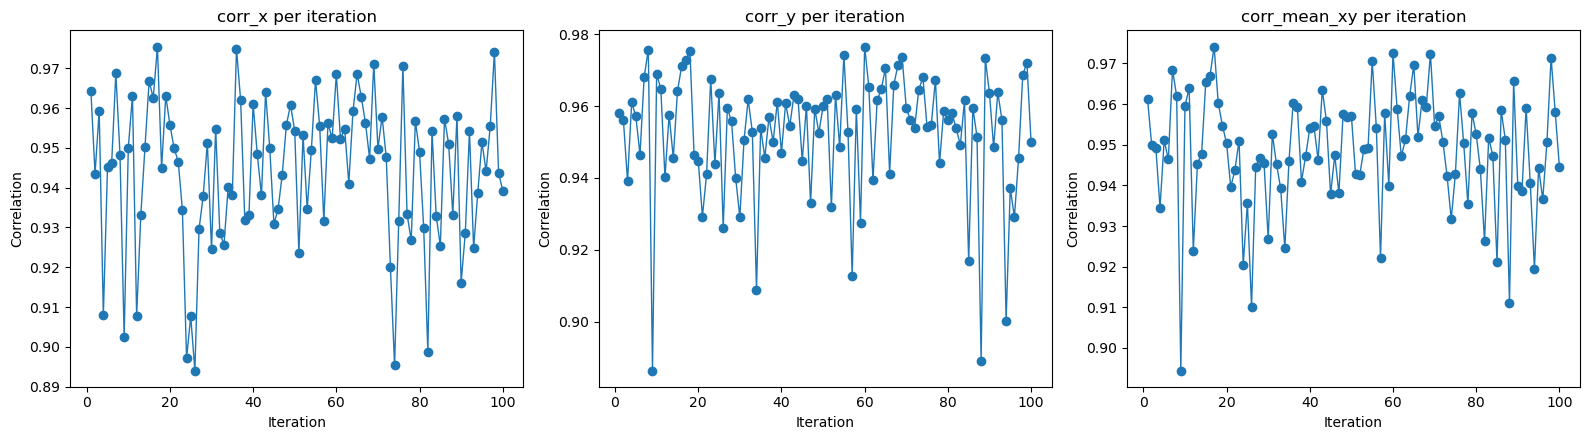

Results saved to: C:\Users\super\OneDrive\Desktop\Desktop2\BEAD_FocalCheck_Slide_LED100mA_Int20_2_BEAD_ROI_A\COM_correlation_results_custom_mask


In [32]:
# =========================
# RUN ITERATIONS
# =========================
iteration_results = run_com_correlation_iterations(
    masked_traces=masked_traces,
    mask_x=mask_x,
    mask_y=mask_y,
    frame_indices=frame_indices,
    n_iterations=N_ITERATIONS,
    base_seed=BASE_RANDOM_SEED,
    report_every=10,
)

display(iteration_results.head())

# =========================
# FINAL SUMMARY
# =========================
mean_corr_x = iteration_results["corr_x"].mean()
mean_corr_y = iteration_results["corr_y"].mean()
mean_corr_xy = iteration_results["corr_mean_xy"].mean()

std_corr_x = iteration_results["corr_x"].std()
std_corr_y = iteration_results["corr_y"].std()
std_corr_xy = iteration_results["corr_mean_xy"].std()

print("Final correlation summary across iterations:")
print(f"Mean corr_x: {mean_corr_x}")
print(f"Mean corr_y: {mean_corr_y}")
print(f"Mean corr_mean_xy: {mean_corr_xy}")
print(f"Std corr_x: {std_corr_x}")
print(f"Std corr_y: {std_corr_y}")
print(f"Std corr_mean_xy: {std_corr_xy}")

# =========================
# VISUALIZATION
# =========================
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(iteration_results["iteration"], iteration_results["corr_x"], marker="o", linewidth=1)
axes[0].set_title("corr_x per iteration")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Correlation")

axes[1].plot(iteration_results["iteration"], iteration_results["corr_y"], marker="o", linewidth=1)
axes[1].set_title("corr_y per iteration")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Correlation")

axes[2].plot(iteration_results["iteration"], iteration_results["corr_mean_xy"], marker="o", linewidth=1)
axes[2].set_title("corr_mean_xy per iteration")
axes[2].set_xlabel("Iteration")
axes[2].set_ylabel("Correlation")

plt.tight_layout()
plt.show()

# =========================
# OPTIONAL SAVE
# =========================
SAVE_RESULTS = True
OUTPUT_DIR = Path(selected_stack_path).parent / "COM_correlation_results_custom_mask"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if SAVE_RESULTS:
    com_a.to_csv(OUTPUT_DIR / "single_assignment_COM_A.csv", index=False)
    com_b.to_csv(OUTPUT_DIR / "single_assignment_COM_B.csv", index=False)
    iteration_results.to_csv(OUTPUT_DIR / "iteration_correlation_summary.csv", index=False)
    print(f"Results saved to: {OUTPUT_DIR}")

## Independent multi mask center fo masses analysis

Defined masks:


,label,x0,y0,r,n_pixels
0,Mask_1,22.0,41.0,18.0,1009


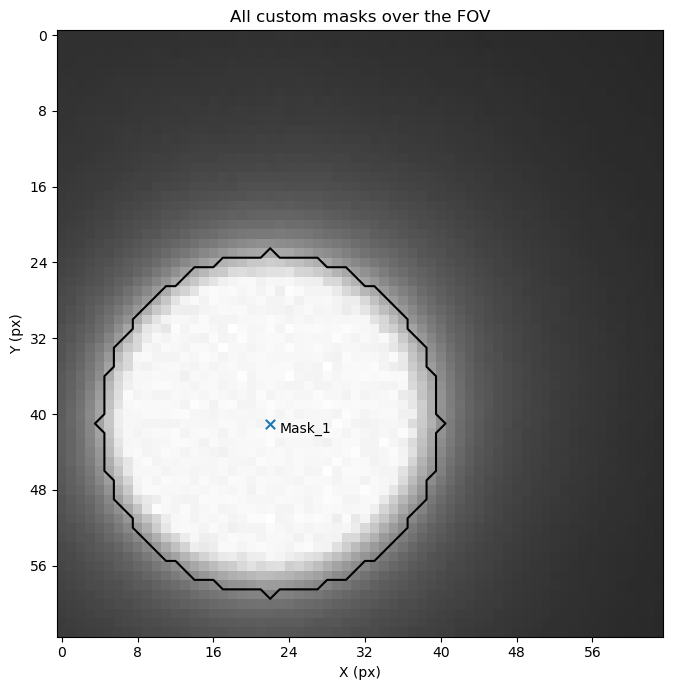

COM extraction completed for all masks.


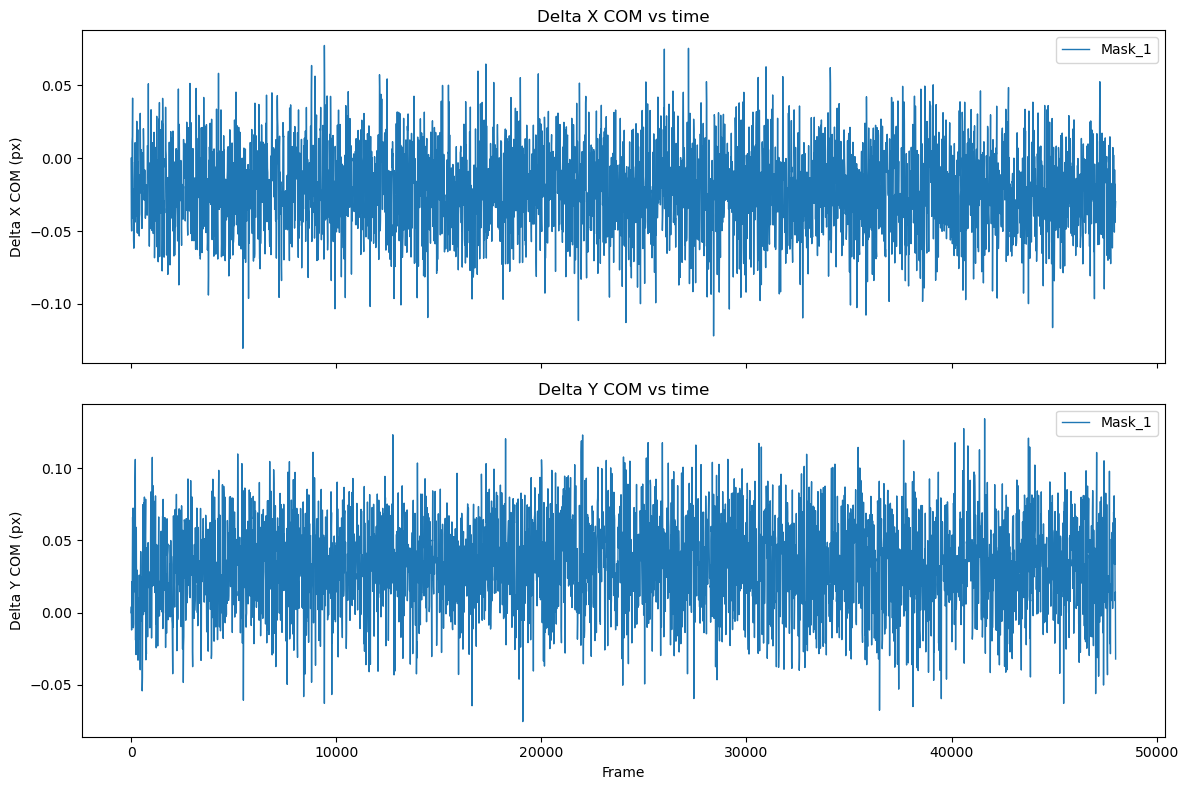

Per-mask delta COM summary:


,label,x0,y0,r,n_pixels,delta_x_mean,delta_x_std,delta_x_min,delta_x_max,delta_y_mean,delta_y_std,delta_y_min,delta_y_max
0,Mask_1,22.0,41.0,18.0,1009,-0.021651,0.029186,-0.146242,0.092044,0.032809,0.03102,-0.08774,0.158009


Pairwise COM correlations:


""


Only one mask is defined. Add at least one more mask to compute pairwise correlations.
Multi-mask results saved to: C:\Users\super\OneDrive\Desktop\Desktop2\BEAD_FocalCheck_Slide_LED100mA_Int20_2_BEAD_ROI_A\COM_correlation_results_multi_mask


In [33]:
# =========================
# MULTI-MASK COM ANALYSIS
# =========================
from itertools import combinations

# =========================
# USER-DEFINED MASK SET
# =========================
# The first mask corresponds to the original custom mask already used in the notebook.
# Add as many extra masks as needed by appending new dictionaries to the list below.
multi_mask_definitions = [
    {"label": "Mask_1", "x0": CUSTOM_MASK_X0, "y0": CUSTOM_MASK_Y0, "r": CUSTOM_MASK_RADIUS},
    #{"label": "Mask_2", "x0": 50.0, "y0": 47.0, "r": 7.5},
    #{"label": "Mask_3", "x0": 49.0, "y0": 50.0, "r": 7.5},
    # {"label": "Mask_2", "x0": 20.0, "y0": 20.0, "r": 7.0},
    # {"label": "Mask_3", "x0": 45.0, "y0": 18.0, "r": 6.0},
]

# =========================
# BUILD ALL MASKS
# =========================
multi_masks = []
for mask_def in multi_mask_definitions:
    current_mask = create_circular_mask(
        height=height,
        width=width,
        center_x=mask_def["x0"],
        center_y=mask_def["y0"],
        radius=mask_def["r"],
    )

    multi_masks.append(
        {
            "label": mask_def["label"],
            "x0": float(mask_def["x0"]),
            "y0": float(mask_def["y0"]),
            "r": float(mask_def["r"]),
            "mask": current_mask,
            "n_pixels": int(np.sum(current_mask)),
        }
    )

multi_mask_summary = pd.DataFrame(
    [
        {
            "label": item["label"],
            "x0": item["x0"],
            "y0": item["y0"],
            "r": item["r"],
            "n_pixels": item["n_pixels"],
        }
        for item in multi_masks
    ]
)

print("Defined masks:")
display(multi_mask_summary)

# =========================
# QC: ALL MASKS OVER THE FOV
# =========================
tick_step = 8
fig, ax = plt.subplots(figsize=(7, 7))

ax.imshow(mean_projection, origin="upper", interpolation="nearest", alpha=0.85)

for idx, item in enumerate(multi_masks):
    ax.contour(item["mask"].astype(np.uint8), levels=[0.5], linewidths=1.5)
    ax.scatter(item["x0"], item["y0"], s=45, marker="x")
    ax.text(item["x0"] + 1.0, item["y0"] + 1.0, item["label"], fontsize=10)

ax.set_title("All custom masks over the FOV")
ax.set_xlabel("X (px)")
ax.set_ylabel("Y (px)")
ax.set_xlim(-0.5, width - 0.5)
ax.set_ylim(height - 0.5, -0.5)
ax.set_xticks(np.arange(0, width, tick_step))
ax.set_yticks(np.arange(0, height, tick_step))

if SHOW_PIXEL_GRID:
    ax.set_xticks(np.arange(-0.5, width, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, height, 1), minor=True)
    ax.grid(which="minor", color="white", alpha=0.15, linewidth=0.3)

plt.tight_layout()
plt.show()

# =========================
# EXTRACT COM SERIES FOR EACH MASK
# =========================
multi_mask_com_results = {}

for item in multi_masks:
    masked_traces, mask_y_local, mask_x_local, frame_indices_local = extract_masked_pixel_traces(
        stack=stack,
        mask_to_use=item["mask"],
        analysis_intervals=ANALYSIS_INTERVALS,
        chunk_size=COM_CHUNK_SIZE,
        output_dtype=np.float32,
    )

    all_pixels_selector = np.ones(mask_x_local.shape[0], dtype=bool)

    com_table = compute_com_series_from_traces(
        masked_traces=masked_traces,
        mask_x=mask_x_local,
        mask_y=mask_y_local,
        class_selector=all_pixels_selector,
        frame_indices=frame_indices_local,
    )

    valid_x = np.isfinite(com_table["x_com"].values)
    valid_y = np.isfinite(com_table["y_com"].values)

    if np.any(valid_x):
        x0_ref = com_table.loc[valid_x, "x_com"].iloc[0]
    else:
        x0_ref = np.nan

    if np.any(valid_y):
        y0_ref = com_table.loc[valid_y, "y_com"].iloc[0]
    else:
        y0_ref = np.nan

    com_table["delta_x_com"] = com_table["x_com"] - x0_ref
    com_table["delta_y_com"] = com_table["y_com"] - y0_ref

    multi_mask_com_results[item["label"]] = {
        "definition": item,
        "com_table": com_table,
    }

print("COM extraction completed for all masks.")

# =========================
# QC: DELTA COM PLOTS FOR EACH MASK
# =========================
n_masks = len(multi_masks)
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for idx, item in enumerate(multi_masks):
    com_table = multi_mask_com_results[item["label"]]["com_table"]

    if len(com_table) > MAX_POINTS_TO_PLOT:
        sampled_indices = np.linspace(0, len(com_table) - 1, MAX_POINTS_TO_PLOT).astype(int)
        com_plot = com_table.iloc[sampled_indices].copy()
    else:
        com_plot = com_table.copy()

    axes[0].plot(
        com_plot["frame"].values,
        com_plot["delta_x_com"].values,
        linewidth=1.0,
        label=item["label"],
    )

    axes[1].plot(
        com_plot["frame"].values,
        com_plot["delta_y_com"].values,
        linewidth=1.0,
        label=item["label"],
    )

axes[0].set_title("Delta X COM vs time")
axes[0].set_ylabel("Delta X COM (px)")
axes[0].legend()

axes[1].set_title("Delta Y COM vs time")
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("Delta Y COM (px)")
axes[1].legend()

plt.tight_layout()
plt.show()

# =========================
# PER-MASK DELTA COM SUMMARY
# =========================
delta_summary_rows = []

for item in multi_masks:
    com_table = multi_mask_com_results[item["label"]]["com_table"]

    delta_summary_rows.append(
        {
            "label": item["label"],
            "x0": item["x0"],
            "y0": item["y0"],
            "r": item["r"],
            "n_pixels": item["n_pixels"],
            "delta_x_mean": np.nanmean(com_table["delta_x_com"].values),
            "delta_x_std": np.nanstd(com_table["delta_x_com"].values),
            "delta_x_min": np.nanmin(com_table["delta_x_com"].values),
            "delta_x_max": np.nanmax(com_table["delta_x_com"].values),
            "delta_y_mean": np.nanmean(com_table["delta_y_com"].values),
            "delta_y_std": np.nanstd(com_table["delta_y_com"].values),
            "delta_y_min": np.nanmin(com_table["delta_y_com"].values),
            "delta_y_max": np.nanmax(com_table["delta_y_com"].values),
        }
    )

delta_summary_df = pd.DataFrame(delta_summary_rows)
print("Per-mask delta COM summary:")
display(delta_summary_df)

# =========================
# PAIRWISE PEARSON CORRELATIONS BETWEEN MASK COM SERIES
# =========================
pairwise_rows = []

for label_a, label_b in combinations([item["label"] for item in multi_masks], 2):
    com_a = multi_mask_com_results[label_a]["com_table"]
    com_b = multi_mask_com_results[label_b]["com_table"]

    corr_x = safe_pearson_correlation(com_a["x_com"].values, com_b["x_com"].values)
    corr_y = safe_pearson_correlation(com_a["y_com"].values, com_b["y_com"].values)
    corr_mean_xy = np.nanmean([corr_x, corr_y])

    corr_delta_x = safe_pearson_correlation(com_a["delta_x_com"].values, com_b["delta_x_com"].values)
    corr_delta_y = safe_pearson_correlation(com_a["delta_y_com"].values, com_b["delta_y_com"].values)
    corr_delta_mean_xy = np.nanmean([corr_delta_x, corr_delta_y])

    pairwise_rows.append(
        {
            "mask_a": label_a,
            "mask_b": label_b,
            "corr_x": corr_x,
            "corr_y": corr_y,
            "corr_mean_xy": corr_mean_xy,
            "corr_delta_x": corr_delta_x,
            "corr_delta_y": corr_delta_y,
            "corr_delta_mean_xy": corr_delta_mean_xy,
        }
    )

pairwise_corr_df = pd.DataFrame(pairwise_rows)

print("Pairwise COM correlations:")
display(pairwise_corr_df)

# =========================
# QC: PAIRWISE DELTA COM OVERLAYS
# =========================
pair_labels = list(combinations([item["label"] for item in multi_masks], 2))

if len(pair_labels) > 0:
    n_pairs = len(pair_labels)
    fig, axes = plt.subplots(n_pairs, 2, figsize=(12, 4 * n_pairs), sharex=False)

    if n_pairs == 1:
        axes = np.array([axes])

    for row_idx, (label_a, label_b) in enumerate(pair_labels):
        com_a = multi_mask_com_results[label_a]["com_table"]
        com_b = multi_mask_com_results[label_b]["com_table"]

        if len(com_a) > MAX_POINTS_TO_PLOT:
            sampled_indices = np.linspace(0, len(com_a) - 1, MAX_POINTS_TO_PLOT).astype(int)
            com_a_plot = com_a.iloc[sampled_indices].copy()
            com_b_plot = com_b.iloc[sampled_indices].copy()
        else:
            com_a_plot = com_a.copy()
            com_b_plot = com_b.copy()

        axes[row_idx, 0].plot(
            com_a_plot["frame"].values,
            com_a_plot["delta_x_com"].values,
            linewidth=1.0,
            label=label_a,
        )
        axes[row_idx, 0].plot(
            com_b_plot["frame"].values,
            com_b_plot["delta_x_com"].values,
            linewidth=1.0,
            label=label_b,
        )
        axes[row_idx, 0].set_title(f"Delta X COM: {label_a} vs {label_b}")
        axes[row_idx, 0].set_xlabel("Frame")
        axes[row_idx, 0].set_ylabel("Delta X COM (px)")
        axes[row_idx, 0].legend()

        axes[row_idx, 1].plot(
            com_a_plot["frame"].values,
            com_a_plot["delta_y_com"].values,
            linewidth=1.0,
            label=label_a,
        )
        axes[row_idx, 1].plot(
            com_b_plot["frame"].values,
            com_b_plot["delta_y_com"].values,
            linewidth=1.0,
            label=label_b,
        )
        axes[row_idx, 1].set_title(f"Delta Y COM: {label_a} vs {label_b}")
        axes[row_idx, 1].set_xlabel("Frame")
        axes[row_idx, 1].set_ylabel("Delta Y COM (px)")
        axes[row_idx, 1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("Only one mask is defined. Add at least one more mask to compute pairwise correlations.")

# =========================
# OPTIONAL SAVE
# =========================
SAVE_MULTI_MASK_RESULTS = True
OUTPUT_DIR_MULTI = Path(selected_stack_path).parent / "COM_correlation_results_multi_mask"
OUTPUT_DIR_MULTI.mkdir(parents=True, exist_ok=True)

if SAVE_MULTI_MASK_RESULTS:
    multi_mask_summary.to_csv(OUTPUT_DIR_MULTI / "multi_mask_definitions.csv", index=False)
    delta_summary_df.to_csv(OUTPUT_DIR_MULTI / "multi_mask_delta_summary.csv", index=False)
    pairwise_corr_df.to_csv(OUTPUT_DIR_MULTI / "multi_mask_pairwise_correlations.csv", index=False)

    for label, result_dict in multi_mask_com_results.items():
        result_dict["com_table"].to_csv(OUTPUT_DIR_MULTI / f"{label}_COM_table.csv", index=False)

    print(f"Multi-mask results saved to: {OUTPUT_DIR_MULTI}")